<a href="https://colab.research.google.com/github/2BerbyMarty2/search-algorithms-2026/blob/main/maze_solver_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Environment Setup & Coordinate Logic
In this section, we initialize the required libraries and define the core logic for the 6x6 maze grid.

### Coordinate System (Rule A)
The maze consists of 36 nodes (0-35). We map these IDs to a 2D Cartesian coordinate system $(x, y)$ where:
* **$x$ (Column):** Determined by the remainder of the Node ID divided by the grid width ($ID \pmod 6$).
* **$y$ (Row):** Determined by the integer division of the Node ID by the grid width ($ID // 6$).

**Example:** Node 15 is calculated as:
* $15 \pmod 6 = 3$ (Column 3)
* $15 // 6 = 2$ (Row 2)
* Result: **(3, 2)**

In [7]:
# Cell 1: Imports and get_coords utility

import random
import heapq
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def get_coords(node_id):
    """
    Converts a Node ID (0-35) into (x, y) coordinates for a 6x6 grid.
    Rule (a): x is the column (0-5), y is the row (0-5).
    Formula: x = ID % 6, y = ID // 6
    """
    x = node_id % 6
    y = node_id // 6
    return (x, y)

# Verification for the report
example_node = 15
print(f"Verification - Node {example_node} maps to coordinates: {get_coords(example_node)}")

Verification - Node 15 maps to coordinates: (3, 2)


# 2. Maze Environment Initialization (Task 1)
In this section, we generate a randomized maze environment. To ensure a valid and challenging pathfinding problem, we follow three specific constraints for node selection:

### Constraint Rules:
* **Rule (b):** The **Start Node** must be randomly selected from IDs **0–11** (the top two rows of the grid).
* **Rule (c):** The **Goal Node** must be randomly selected from IDs **24–35** (the bottom two rows of the grid).
* **Rule (d):** **Four Barrier Nodes** are randomly selected from the remaining 34 nodes to act as obstacles.

We use a helper function to visualize the resulting maze in a text-based grid format where:
* `S` = Start Point
* `G` = Goal Point
* `X` = Barrier (Obstacle)
* `.` = Traversable Path

In [8]:
# Cell 2: Maze Setup (Randomly picking nodes and printing them)

def setup_maze():
    # 1. Initialize all possible nodes (0 to 35)
    all_node_ids = list(range(36))

    # 2. Rule (b): Randomly select a node within 0-11 as the starting node
    start_id = random.randint(0, 11)

    # 3. Rule (c): Randomly select a node within 24-35 as the goal node
    goal_id = random.randint(24, 35)

    # 4. Rule (d): Randomly select 4 barrier nodes from the remaining 34 nodes
    # We create a list of potential nodes excluding the ones already used for start/goal
    remaining_ids = [n for n in all_node_ids if n != start_id and n != goal_id]
    barrier_ids = random.sample(remaining_ids, 4)

    # Convert IDs to Coordinates using our Cell 1 utility
    start_coords = get_coords(start_id)
    goal_coords = get_coords(goal_id)
    barriers_coords = [get_coords(bid) for bid in barrier_ids]

    # Print numerical results for the report
    print("--- Task 1: Maze Configuration ---")
    print(f"Start Node: ID {start_id} at {start_coords}")
    print(f"Goal Node:  ID {goal_id} at {goal_coords}")
    print(f"Barriers:   IDs {barrier_ids} at {barriers_coords}")

    # Simple Text Visualization of the Grid
    print("\nText Representation (S=Start, G=Goal, X=Barrier):")
    for y in range(6):
        row_str = ""
        for x in range(6):
            current = (x, y)
            if current == start_coords:
                row_str += " S "
            elif current == goal_coords:
                row_str += " G "
            elif current in barriers_coords:
                row_str += " X "
            else:
                row_str += " . "
        print(row_str)

    return start_coords, goal_coords, barriers_coords

# Execute the setup and store the variables for the next cells
start_node, goal_node, barriers = setup_maze()

--- Task 1: Maze Configuration ---
Start Node: ID 5 at (5, 0)
Goal Node:  ID 32 at (2, 5)
Barriers:   IDs [26, 29, 23, 12] at [(2, 4), (5, 4), (5, 3), (0, 2)]

Text Representation (S=Start, G=Goal, X=Barrier):
 .  .  .  .  .  S 
 .  .  .  .  .  . 
 X  .  .  .  .  . 
 .  .  .  .  .  X 
 .  .  X  .  .  X 
 .  .  G  .  .  . 


# 3. Graphical Visualization Utility
To better understand the agent's behavior and the search environment, we utilize `matplotlib` to render a 2D graphical representation of the 6x6 maze.

### Visual Key:
* **Green Square (S):** The randomized starting position.
* **Red Square (G):** The target goal position.
* **Black Squares:** Barrier nodes that the agent cannot pass through.
* **Blue Line:** The final path calculated by the search algorithms.

**Note:** Since standard plotting libraries place the origin $(0,0)$ at the bottom-left, we apply a coordinate transformation ($5 - y$) to ensure the visualization matches the "Row 0 = Top" convention of the maze layout.

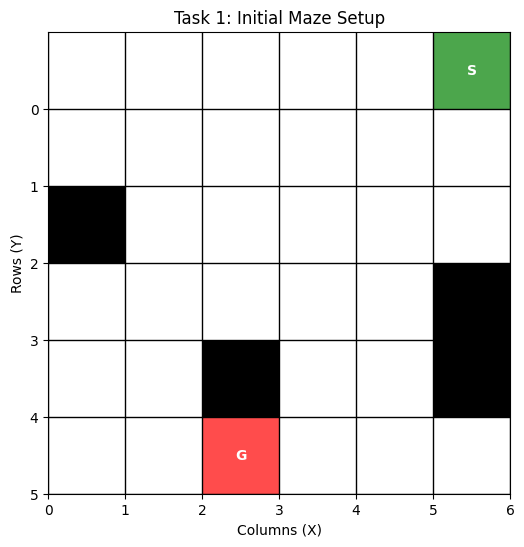

In [9]:
# Cell: Visualization Utility

def visualize_maze(start, goal, barriers, path=None, title="Maze Visualization"):
    """
    Draws a 6x6 grid with Start, Goal, and Barriers.
    Optionally draws a path if one is provided.
    """
    fig, ax = plt.subplots(figsize=(6, 6))

    # Set grid limits (0 to 6)
    ax.set_xlim(0, 6)
    ax.set_ylim(0, 6)

    # Draw the grid lines
    ax.set_xticks(range(7))
    ax.set_yticks(range(6)) # Changed from range(7) to range(6) to match the 6 labels
    ax.grid(True, color='black', linewidth=1)

    # Draw Barriers (Black squares)
    for (bx, by) in barriers:
        # We use (5-by) because matplotlib's (0,0) is bottom-left,
        # but our Maze's Row 0 is at the top.
        rect = patches.Rectangle((bx, 5-by), 1, 1, facecolor='black')
        ax.add_patch(rect)

    # Draw Start (Green) and Goal (Red)
    start_rect = patches.Rectangle((start[0], 5-start[1]), 1, 1, facecolor='green', alpha=0.7)
    goal_rect = patches.Rectangle((goal[0], 5-goal[1]), 1, 1, facecolor='red', alpha=0.7)
    ax.add_patch(start_rect)
    ax.add_patch(goal_rect)

    # Add Text Labels 'S' and 'G' in the middle of the squares
    ax.text(start[0]+0.5, 5-start[1]+0.5, 'S', ha='center', va='center', color='white', weight='bold')
    ax.text(goal[0]+0.5, 5-goal[1]+0.5, 'G', ha='center', va='center', color='white', weight='bold')

    # Draw Path if provided (Blue line connecting the dots)
    if path:
        # Convert path coordinates to plot centers
        px = [p[0] + 0.5 for p in path]
        py = [5 - p[1] + 0.5 for p in path]
        ax.plot(px, py, marker='o', color='blue', linewidth=3, markersize=8, label="Path")

    # Clean up axes to match the coursework image
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title(title)
    plt.xlabel("Columns (X)")
    plt.ylabel("Rows (Y)")

    # Relabel Y-axis to show 0 at the top and 5 at the bottom
    plt.gca().set_yticklabels(['5','4','3','2','1','0'])

    plt.show()

# --- Call the visualization for Task 1 ---
visualize_maze(start_node, goal_node, barriers, title="Task 1: Initial Maze Setup")

# 4. Iterative Deepening Depth-First Search (IDDFS)
Iterative Deepening DFS is a state-space search strategy that repeatedly performs a **Depth-Limited Search (DLS)** with increasing depth limits ($0, 1, 2, \dots$) until the goal is found.

### Why use IDDFS?
* **Optimality:** Unlike standard DFS, IDDFS is guaranteed to find the shortest path in an unweighted grid (similar to Breadth-First Search).
* **Memory Efficiency:** It uses only $O(bd)$ space (where $b$ is the branching factor and $d$ is the depth), whereas BFS requires $O(b^d)$.
* **Blind Search:** It does not require a heuristic to navigate; it explores all possible directions systematically.

Starting IDDFS Search...
Path found at depth limit: 8
IDDFS Path: [(5, 0), (4, 0), (3, 0), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (2, 5)]


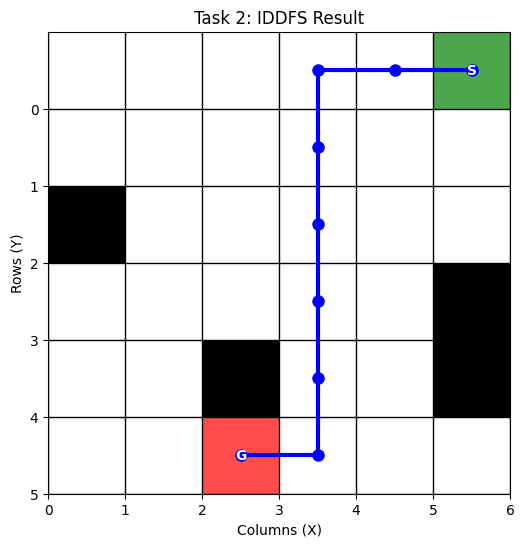

In [10]:
# Cell 3: Iterative Deepening DFS (Task 2)

def get_neighbors(node, barriers):
    """Returns valid adjacent (up, down, left, right) nodes."""
    x, y = node
    neighbors = []
    # Possible moves: Right, Left, Down, Up
    for dx, dy in [(1, 0), (-1, 0), (0, 1), (0, -1)]:
        nx, ny = x + dx, y + dy
        # Rule Check: Must be within 6x6 grid and NOT a barrier
        if 0 <= nx < 6 and 0 <= ny < 6 and (nx, ny) not in barriers:
            neighbors.append((nx, ny))
    return neighbors

def dls(current, goal, barriers, limit, path):
    """Depth-Limited Search helper function."""
    if current == goal:
        return path + [current]
    if limit <= 0:
        return None

    for neighbor in get_neighbors(current, barriers):
        if neighbor not in path: # Avoid cycles
            result = dls(neighbor, goal, barriers, limit - 1, path + [current])
            if result is not None:
                return result
    return None

def iddfs(start, goal, barriers):
    """Main IDDFS algorithm that increases depth limit iteratively."""
    print("Starting IDDFS Search...")
    for depth in range(36): # Maximum possible depth in a 6x6 grid is 36
        result = dls(start, goal, barriers, depth, [])
        if result:
            print(f"Path found at depth limit: {depth}")
            return result
    return None

# Execute IDDFS
iddfs_path = iddfs(start_node, goal_node, barriers)

if iddfs_path:
    print(f"IDDFS Path: {iddfs_path}")
    # Use the visualization utility from the previous step
    visualize_maze(start_node, goal_node, barriers, path=iddfs_path, title="Task 2: IDDFS Result")
else:
    print("IDDFS could not find a path.")

# 5. Best First Search (Informed Search)
Best First Search is an "informed" search algorithm that uses an evaluation function (Heuristic) to decide which node to explore next. Instead of searching level-by-level, it prioritizes nodes that appear to be closest to the goal.

### The Manhattan Distance Heuristic
Since our agent can only move in cardinal directions (Up, Down, Left, Right) and not diagonally, we use the **Manhattan Distance** formula:
$$h(n) = |x_1 - x_2| + |y_1 - y_2|$$

### Why use Best First Search?
* **Efficiency:** By focusing on the goal, the algorithm usually explores significantly fewer nodes than IDDFS or BFS.
* **Priority Queue:** We use a min-priority queue (`heapq`) to always extract the node with the lowest heuristic value for expansion.

Starting Best First Search...
Path found! Nodes explored: 11
BFS Path: [(5, 0), (4, 0), (3, 0), (2, 0), (2, 1), (2, 2), (2, 3), (1, 3), (1, 4), (1, 5), (2, 5)]


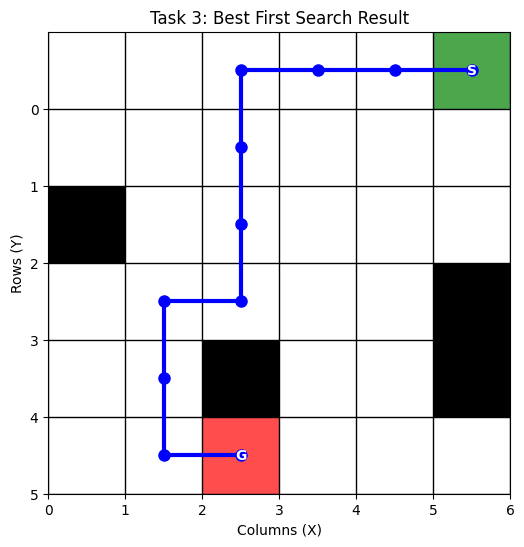

In [11]:
# Cell 4: Best First Search (Task 3)

def manhattan_distance(node, goal):
    """
    Heuristic function: Calculates the Manhattan distance between two points.
    Formula: |x1 - x2| + |y1 - y2|
    """
    return abs(node[0] - goal[0]) + abs(node[1] - goal[1])

def best_first_search(start, goal, barriers):
    """
    Informed search algorithm that uses a heuristic to prioritize nodes.
    """
    print("Starting Best First Search...")

    # Priority Queue stores: (heuristic_priority, current_node, path_taken)
    # Priority is the estimated distance to the goal.
    frontier = []
    heapq.heappush(frontier, (manhattan_distance(start, goal), start, []))

    visited = set()
    nodes_explored = 0

    while frontier:
        priority, current, path = heapq.heappop(frontier)
        nodes_explored += 1

        if current == goal:
            print(f"Path found! Nodes explored: {nodes_explored}")
            return path + [current]

        if current not in visited:
            visited.add(current)
            for neighbor in get_neighbors(current, barriers):
                if neighbor not in visited:
                    h = manhattan_distance(neighbor, goal)
                    heapq.heappush(frontier, (h, neighbor, path + [current]))

    return None

# Execute Best First Search
bfs_path = best_first_search(start_node, goal_node, barriers)

if bfs_path:
    print(f"BFS Path: {bfs_path}")
    # Use the visualization utility
    visualize_maze(start_node, goal_node, barriers, path=bfs_path, title="Task 3: Best First Search Result")
else:
    print("Best First Search could not find a path.")

# 6. Performance Comparison & Analysis
The final step is to evaluate the two strategies against the same environment. We compare them based on **Path Optimality** (was the shortest path found?) and **Search Efficiency** (how many states were visited?).

### Key Insights:
* **IDDFS (Blind):** Guaranteed to find the shortest path in this unweighted grid. However, it is computationally redundant because it re-explores levels multiple times as the depth limit increases.
* **Best First Search (Informed):** Uses the Manhattan heuristic to "ignore" directions that move away from the goal. This typically results in a significantly lower number of explored nodes, making it ideal for larger state spaces.

In [12]:
# Cell 5: Comparison & Performance Analysis

def run_comparison(start, goal, barriers):
    print("--- Algorithm Comparison Results ---")

    # Run IDDFS
    iddfs_res = iddfs(start, goal, barriers)
    iddfs_len = len(iddfs_res) if iddfs_res else "N/A"

    # Run Best First Search
    bfs_res = best_first_search(start, goal, barriers)
    bfs_len = len(bfs_res) if bfs_res else "N/A"

    print("\n" + "="*30)
    print(f"{'Metric':<20} | {'IDDFS':<10} | {'Best First':<10}")
    print("-" * 45)
    print(f"{'Path Found?':<20} | {'Yes' if iddfs_res else 'No':<10} | {'Yes' if bfs_res else 'No':<10}")
    print(f"{'Path Length (Steps)':<20} | {iddfs_len:<10} | {bfs_len:<10}")
    print("="*30)

    if iddfs_res == bfs_res:
        print("\nObservation: Both algorithms found the same path.")
    else:
        print("\nObservation: The algorithms found different paths.")

# Run the final comparison
run_comparison(start_node, goal_node, barriers)

--- Algorithm Comparison Results ---
Starting IDDFS Search...
Path found at depth limit: 8
Starting Best First Search...
Path found! Nodes explored: 11

Metric               | IDDFS      | Best First
---------------------------------------------
Path Found?          | Yes        | Yes       
Path Length (Steps)  | 9          | 11        

Observation: The algorithms found different paths.
